# Installing dependancies

In [1]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install squarify
%pip install seaborn
%pip install plotly
%pip install scikit-learn
%pip install lifetimes
%pip install nb_black
%pip install nbformat


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: fastjsonschema in d:\programmes\coding\python\lib\site-packages (from nbformat) (2.16.3)



In [3]:
import os
import squarify
import warnings
import pandas as pd
from operator import attrgetter
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objs as go
from plotly.offline import iplot
from sklearn.metrics import (silhouette_score,
                             calinski_harabasz_score,
                             davies_bouldin_score)
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import plot_period_transactions
# allows plotting of graphs in the output cell of Jupyter Notebook.
%matplotlib inline
#loads the "black" code formatter extension for Jupyter Notebook, which automatically formats Python code cells to follow PEP 8
%load_ext nb_black
# suppresses warning messages that may appear during data analysis.
warnings.filterwarnings('ignore')
#sets the plotting style to "whitegrid" in Seaborn, which adds white gridlines to the background of the plot.
sns.set_style('whitegrid')
#sets the color palette for Seaborn to "Set2", which is a predefined color scheme.
palette = 'Set2'

<IPython.core.display.Javascript object>

In [4]:
path = 'Data/'

df = pd.read_csv(os.path.join(path, 'data.csv'),
                 header=0,
                 encoding='unicode_escape',
                 dtype={'CustomerID': str,
                        'InvoiceID': str},
                 parse_dates=['InvoiceDate'],
                 infer_datetime_format=True)
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


<IPython.core.display.Javascript object>

# Compréhension des données

In [5]:
from IPython.display import display

def check_data(dataframe, head=5):
    print(" SHAPE ".center(70, '-'))
    print('Rows: {}'.format(dataframe.shape[0]))
    print('Columns: {}'.format(dataframe.shape[1]))
    print(" TYPES ".center(70, '-'))
    # show types in a table format
    display(df.dtypes.to_frame().rename(columns={0: 'dtype'}))
    print(" HEAD ".center(70, '-'))
    display(dataframe.head(head))
    print(" TAIL ".center(70, '-'))
    display(dataframe.tail(head))
    print(" MISSING VALUES ".center(70, '-'))
    display(pd.DataFrame(dataframe.isnull().sum(), columns=["Count"]))
    print(" DUPLICATED VALUES ".center(70, '-'))
    display(pd.DataFrame({dataframe.duplicated().sum()}, columns=["Count"]))
    print(" QUANTILES ".center(70, '-'))
    display(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)


check_data(df)


------------------------------- SHAPE --------------------------------
Rows: 541909
Columns: 8
------------------------------- TYPES --------------------------------


,dtype
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,object
Country,object


-------------------------------- HEAD --------------------------------


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


-------------------------------- TAIL --------------------------------


...

------------------------- DUPLICATED VALUES --------------------------


,Count
0,5268


----------------------------- QUANTILES ------------------------------


,0.00,0.05,0.50,0.95,0.99,1.00
Quantity,-80995.00,1.00,3.00,29.00,100.0,80995.0
UnitPrice,-11062.06,0.42,2.08,9.95,18.0,38970.0


<IPython.core.display.Javascript object>

In [6]:
world_map = df[['CustomerID', 'InvoiceNo', 'Country']
               ].groupby(['CustomerID', 'InvoiceNo', 'Country']
                         ).count().reset_index(drop=False)


countries = world_map['Country'].value_counts()
data = dict(type='choropleth',
            locations=countries.index,
            locationmode='country names',
            z=countries,
            text=countries.index,
            colorbar={'title': 'Orders'},
            colorscale='Viridis',
            reversescale=False)

layout = dict(title={'text': "Number of Orders by Countries",
                     'y': 0.9,
                     'x': 0.5,
                     'xanchor': 'center',
                     'yanchor': 'top'},
              geo=dict(resolution=50,
                       showocean=True,
                       oceancolor="LightBlue",
                       showland=True,
                       landcolor="whitesmoke",
                       showframe=True),
              template='plotly_white',
              height=500,
              width=1000)

choromap = go.Figure(data=[data], layout=layout)
iplot(choromap, validate=False)


<IPython.core.display.Javascript object>

# Descriptive Statistics

Les statistiques descriptives sont un ensemble de méthodes utilisées pour décrire et résumer les principales caractéristiques d'un ensemble de données. Ils comprennent des mesures telles que la tendance centrale (moyenne, médiane, mode), la dispersion (écart type, intervalle, intervalle interquartile), l'asymétrie, l'aplatissement et la corrélation. Les statistiques descriptives permettent de comprendre la distribution des données et d'identifier les valeurs aberrantes ou les modèles dans l'ensemble de données. Ils constituent une première étape importante dans l'analyse des données et sont souvent utilisés pour éclairer d'autres modélisations statistiques et tests d'hypothèses.

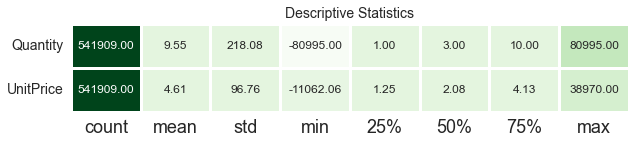

<IPython.core.display.Javascript object>

In [7]:
def desc_stats(dataframe):
    desc_df = pd.DataFrame(index=dataframe.columns,
                           columns=dataframe.describe().T.columns,
                           data=dataframe.describe().T)

    f, ax = plt.subplots(figsize=(10,
                                  desc_df.shape[0] * 0.81))
    sns.heatmap(desc_df,
                annot=True,
                cmap="Greens",
                fmt='.2f',
                ax=ax,
                linecolor='white',
                linewidths=1.1,
                cbar=False,
                annot_kws={"size": 12}
            )
    plt.xticks(size=18)
    plt.yticks(size=14,
               rotation=0)
    plt.title("Descriptive Statistics", size=14)
    plt.show()


desc_stats(df.select_dtypes(include=[float, int]))


# Data Preprocessing

Dans les statistiques descriptives, l'intervalle interquartile vous indique la propagation de la moitié médiane de votre distribution. Les quartiles segmentent toute distribution ordonnée de bas en haut en quatre parties égales. La plage interquartile (IQR) contient les deuxième et troisième quartiles, ou la moitié médiane de votre ensemble de données.

In [8]:
def replace_with_thresholds(dataframe, variable, q1=0.25, q3=0.75):
    '''
    Detects outliers with IQR method and replaces with thresholds 
    
    '''

    df_ = dataframe.copy()
    quartile1 = df_[variable].quantile(q1)
    quartile3 = df_[variable].quantile(q3)
    iqr = quartile3 - quartile1

    up_limit = quartile3 + 1.5 * iqr
    low_limit = quartile1 - 1.5 * iqr
    # si la valeur de la variable est inférieure à la limite inférieure, elle est remplacée par cette limite inférieure.
    df_.loc[(df_[variable] < low_limit), variable] = low_limit
    # si la valeur de la variable est supérieure à la limite supérieure, elle est remplacée par cette limite supérieure.
    df_.loc[(df_[variable] > up_limit), variable] = up_limit

    return df_

#Ce code effectue plusieurs étapes de nettoyage et de prétraitement des données
def ecommerce_preprocess(dataframe):
    df_ = dataframe.copy()

    #Missing Values
    df_ = df_.dropna()

    #supprimer les commandes annulées et la quantité = 0
    df_ = df_[~df_['InvoiceNo'].str.contains('C', na=False)]
    df_ = df_[df_['Quantity'] > 0]

    #Remplacement des valeurs aberrantes
    df_ = replace_with_thresholds(df_, "Quantity", q1=0.01, q3=0.99)
    df_ = replace_with_thresholds(df_, "UnitPrice", q1=0.01, q3=0.99)

    #Total Price
    df_["TotalPrice"] = df_["Quantity"] * df_["UnitPrice"]

    return df_


<IPython.core.display.Javascript object>

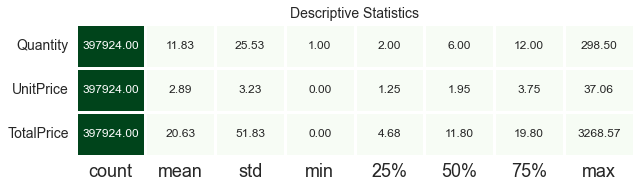

<IPython.core.display.Javascript object>

In [9]:
df = ecommerce_preprocess(df)

desc_stats(df.select_dtypes(include=[float, int]))


# RFM Analysis

## RFM Metrics

In [10]:
print(df['InvoiceDate'].max())

2011-12-09 12:50:00


<IPython.core.display.Javascript object>

In [11]:
import datetime as dt

today_date = dt.datetime(2011, 12, 11)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (today_date - x.max()).days,
    'InvoiceNo': lambda x: x.nunique(),
    'TotalPrice': lambda x: x.sum()
})

rfm.columns = ['recency', 'frequency', 'monetary']
# filter the 'monetary' column using boolean condition
rfm = rfm[rfm['monetary'] > 0]
rfm = rfm.reset_index()

rfm.head()


,CustomerID,recency,frequency,monetary
0,12346,326,1,310.44
1,12347,3,7,4310.00
2,12348,76,4,1770.78
3,12349,19,1,1491.72
4,12350,311,1,331.46


<IPython.core.display.Javascript object>

# RFM Scores

Ce code définit une fonction <code>get_rfm_scores</code> qui prend une trame de données (DataFrame) <code>dataframe</code> en entrée, crée des copies de la DataFrame d'entrée, calcule les scores RFM (Récence, Fréquence et Monétaire) des clients, puis renvoie la DataFrame résultante.

La fonction calcule le score de récence en divisant la colonne de récence en <b>5 quantiles</b> à l'aide de <code>pd.qcut</code> et en attribuant les étiquettes 5, 4, 3, 2, 1 à chaque quantile. Il calcule le score de fréquence en calculant le rang de chaque valeur dans la colonne Fréquence et en les divisant en 5 quantiles à l'aide de <code>pd.qcut</code>. Il attribue les étiquettes 1, 2, 3, 4, 5 à chaque quantile.Puis il calcule le score monétaire de la même manière que le score de récence, en divisant la colonne monétaire en 5 quantiles à l'aide de <code>pd.qcut</code> et en attribuant les étiquettes 1, 2, 3, 4, 5 à chaque quantile.

La fonction combine ensuite les scores de récence et de fréquence en les concaténant sous forme de chaînes à l'aide de la méthode <code>astype</code>, et attribue la valeur résultante à une nouvelle colonne appelée <code>RFM_SCORE</code>.

La fonction renvoie le DataFrame résultant avec les colonnes `recency_score`, ``frequency_score``, ``Monetary_score`` et ``RFM_SCORE`` ajoutées.

Enfin, la fonction est appelée avec le rfm DataFrame en entrée, et le DataFrame résultant est affecté à une variable appelée <code>rfm</code>.

<h4>Remarque:</h4> 
``qcut`` signifie coupe quantile, et c'est une méthode dans Pandas qui est utilisée pour classer les variables numériques en intervalles discrets basés sur les quantiles des données. Elle est utile pour créer des variables catégorielles basées sur la distribution d'une variable continue. Il est couramment utilisé dans l'analyse RFM (Récence, Fréquence, Monétaire), qui est une méthode de segmentation des clients en fonction de l'historique de leurs transactions.

In [13]:
def get_rfm_scores(dataframe) -> pd.core.frame.DataFrame:

    df_ = dataframe.copy()
    df_["recency_score"] = pd.qcut(df_["recency"], 5, labels=[5, 4, 3, 2, 1])
    df_["frequency_score"] = pd.qcut(
        df_["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]
    )
    df_["monetary_score"] = pd.qcut(df_["monetary"], 5, labels=[1, 2, 3, 4, 5])
    df_["RFM_SCORE"] = df_["recency_score"].astype(str) + df_["frequency_score"].astype(str)

    return df_


rfm = get_rfm_scores(rfm)


<IPython.core.display.Javascript object>

# Segmentation

La colonne `` rfm['RFM_SCORE'] `` est utilisée pour faire correspondre les expressions régulières dans ``seg_map``, et les noms de segment résultants sont stockés dans une nouvelle colonne ``rfm['segment']``.

In [18]:
seg_map = {r'[1-2][1-2]': 'en hibernation',
           r'[1-2][3-4]': 'en risque',
           r'[1-2]5': 'ne peut pas perdre',
           r'3[1-2]': 'prsq dormant',
           r'33': 'besoin d\'attention',
           r'[3-4][4-5]': 'clients fidèles',
           r'41': 'prometteur',
           r'51': 'nouveaux clients',
           r'[4-5][2-3]': 'loyal_potentiels',
           r'5[4-5]': 'champions'}

rfm['segment'] = rfm['RFM_SCORE'].replace(seg_map, regex=True)

rfm.head()


,CustomerID,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE,segment
0,12346,326,1,310.44,1,1,2,11,en hibernation
1,12347,3,7,4310.00,5,5,5,55,champions
2,12348,76,4,1770.78,2,4,4,24,en risque
3,12349,19,1,1491.72,4,1,4,41,prometteur
4,12350,311,1,331.46,1,1,2,11,en hibernation


<IPython.core.display.Javascript object>

# Segmentation Map

La carte de segmentation est définie comme un dictionnaire ``seg_map`` où chaque clé est un modèle d'expression régulière qui correspond à une plage spécifique de scores RFM, et chaque valeur est le nom du segment associé à cette plage de scores.

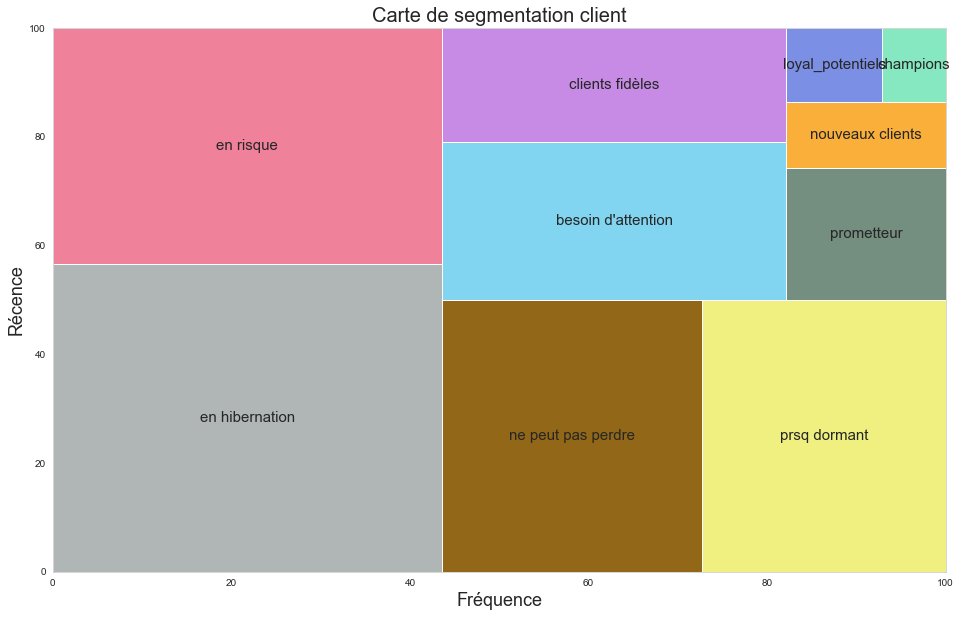

<IPython.core.display.Javascript object>

In [21]:
segments = rfm["segment"].value_counts().sort_values(ascending=False)
fig = plt.gcf()
ax = fig.add_subplot()
fig.set_size_inches(16, 10)
squarify.plot(
    sizes=segments,
    label=[label for label in seg_map.values()],
    color=[
        "#AFB6B5",
        "#F0819A",
        "#926717",
        "#F0F081",
        "#81D5F0",
        "#C78BE5",
        "#748E80",
        "#FAAF3A",
        "#7B8FE4",
        "#86E8C0",
    ],
    pad=False,
    bar_kwargs={"alpha": 1},
    text_kwargs={"fontsize": 15},
)
plt.title("Carte de segmentation client", fontsize=20)
plt.xlabel("Fréquence", fontsize=18)
plt.ylabel("Récence", fontsize=18)
plt.show()

# Model Evaluation

Le code suivant évalue le modèle RFM à l'aide de différentes métriques d'évaluation de clustering.

- La variable ``X`` représente les caractéristiques d'entrée utilisées dans le clustering, dans ce cas, les colonnes « ``recency_score`` » et « ``frequency_score`` » de la trame de données RFM.
- La variable ``labels`` représente les labels de cluster attribués par le modèle de segmentation, qui sont la colonne « segment » de la trame de données RFM.
- ``silhouette_score`` mesure la similarité d'une observation avec son propre cluster par rapport aux autres clusters. **Plus le score est proche de 1, meilleur est le regroupement.**
- ``calinski_harabasz_score`` mesure le rapport entre la dispersion intra-cluster et la dispersion inter-cluster. **Un score plus élevé indique une meilleure séparation entre les clusters**.
- ``davies_bouldin_score`` mesure la similarité moyenne entre chaque cluster et son cluster le plus similaire. **Plus le score est faible, meilleur est le regroupement.**
La sortie de ce code montre le nombre d'observations et de segments, ainsi que les valeurs des trois métriques d'évaluation pour le modèle RFM.

In [26]:
from IPython.display import display, HTML
X = rfm[['recency_score', 'frequency_score']]
labels = rfm['segment']
results = {
    'Number of Observations': [X.shape[0]],
    'Number of Segments': [labels.nunique()],
    'Silhouette Score': [round(silhouette_score(X, labels), 3)],
    'Calinski Harabasz Score': [round(calinski_harabasz_score(X, labels), 3)],
    'Davies Bouldin Score': [round(davies_bouldin_score(X, labels), 3)]
}
df_results = pd.DataFrame(results)

display(HTML("<h1 style='text-align:center;'>RFM Model Evaluation</h1>"))
display(HTML(df_results.to_html(index=False)))
display(HTML("<hr style='border:2px solid gray'>"))


Number of Observations,Number of Segments,Silhouette Score,Calinski Harabasz Score,Davies Bouldin Score
4338,10,0.471,4590.526,0.633


<IPython.core.display.Javascript object>

# Segment Analysis

In [27]:
# sélectionne uniquement les colonnes 'récence', 'monétaire', 'fréquence' et 'segment' du RFM DataFrame.
# regroupe le DataFrame par la colonne 'segment'.
# applique les fonctions d'agrégation 'mean', 'std', 'max' et 'min' à chaque colonne pour chaque groupe de segments.
rfm[['recency', 'monetary', 'frequency', 'segment']]\
.groupby('segment')\
.agg({'mean','std','max','min'})

recency                           monetary              \
                          std  max        mean min           std         max   
segment                                                                        
besoin d'attention  11.552074   72   52.427807  34    732.298552    4353.830   
champions            3.683300   13    6.361769   1  18366.105822  266163.525   
clients fidèles     15.577050   72   33.608059  15   5405.787839  120210.355   
en hibernation      92.013560  374  217.605042  73    553.714975    9182.345   
en risque           68.618828  374  153.785835  73    943.170824   11072.670   
loyal_potentiels     9.338808   33   17.398760   1    601.746293    4628.750   
ne peut pas perdre  65.250378  373  132.968254  73   2008.352354   10254.180   
nouveaux clients     3.902112   13    7.428571   1    174.620952     848.550   
prometteur           5.192519   33   23.510638  15    223.634736    1491.720   
prsq dormant        10.943474   72   53.312500  34    533.161343    6207.670   

                                         frequency                      
                           mean     min        std  max       mean min  
segment                                                                 
besoin d'attention   847.657086    6.90   0.470081    3   2.326203   2  
champions           6498.612978  198.23  16.476484  210  12.417062   3  
clients fidèles     2752.519574   36.56   4.545669   63   6.479853   3  
en hibernation       398.573036    3.75   0.302492    2   1.101774   1  
en risque            938.458341   52.00   0.954415    6   2.878583   2  
loyal_potentiels     674.628357   20.80   0.651401    3   2.010331   1  
ne peut pas perdre  2646.822540   70.02   4.289630   34   8.380952   6  
nouveaux clients     314.883690   89.94   0.000000    1   1.000000   1  
prometteur           285.623723   30.00   0.000000    1   1.000000   1  
prsq dormant         469.058097    6.20   0.368913    2   1.161932   1

<IPython.core.display.Javascript object>

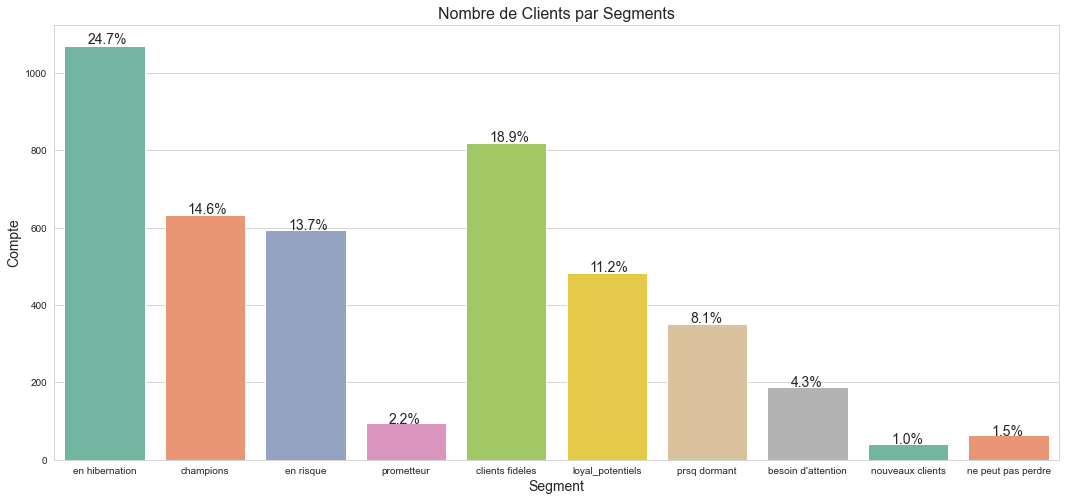

<IPython.core.display.Javascript object>

In [28]:
plt.figure(figsize=(18, 8))
ax = sns.countplot(data=rfm,
                   x='segment',
                   palette=palette)
total = len(rfm.segment)
for patch in ax.patches:
    percentage = '{:.1f}%'.format(100 * patch.get_height()/total)
    x = patch.get_x() + patch.get_width() / 2 - 0.17
    y = patch.get_y() + patch.get_height() * 1.005
    ax.annotate(percentage, (x, y), size=14)
plt.title('Nombre de Clients par Segments', size=16)
plt.xlabel('Segment', size=14)
plt.ylabel('Compte', size=14)
plt.xticks(size=10)
plt.yticks(size=10)
plt.show()

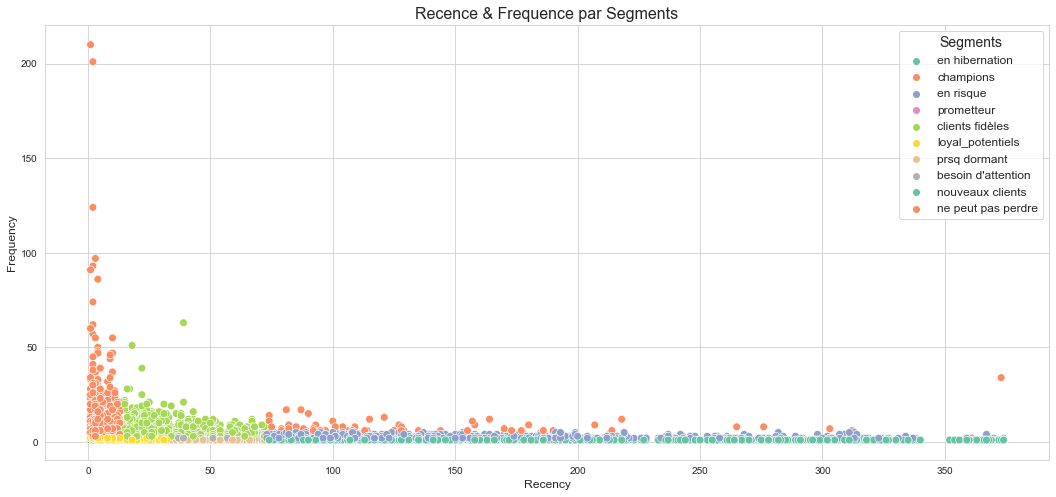

<IPython.core.display.Javascript object>

In [33]:
plt.figure(figsize=(18, 8))
sns.scatterplot(
    data=rfm, x="recency", y="frequency", hue="segment", palette=palette, s=60
)
plt.title("Recence & Frequence par Segments", size=16)
plt.xlabel("Recency", size=12)
plt.ylabel("Frequency", size=12)
plt.xticks(size=10)
plt.yticks(size=10)
plt.legend(loc="best", fontsize=12, title="Segments", title_fontsize=14)
plt.show()


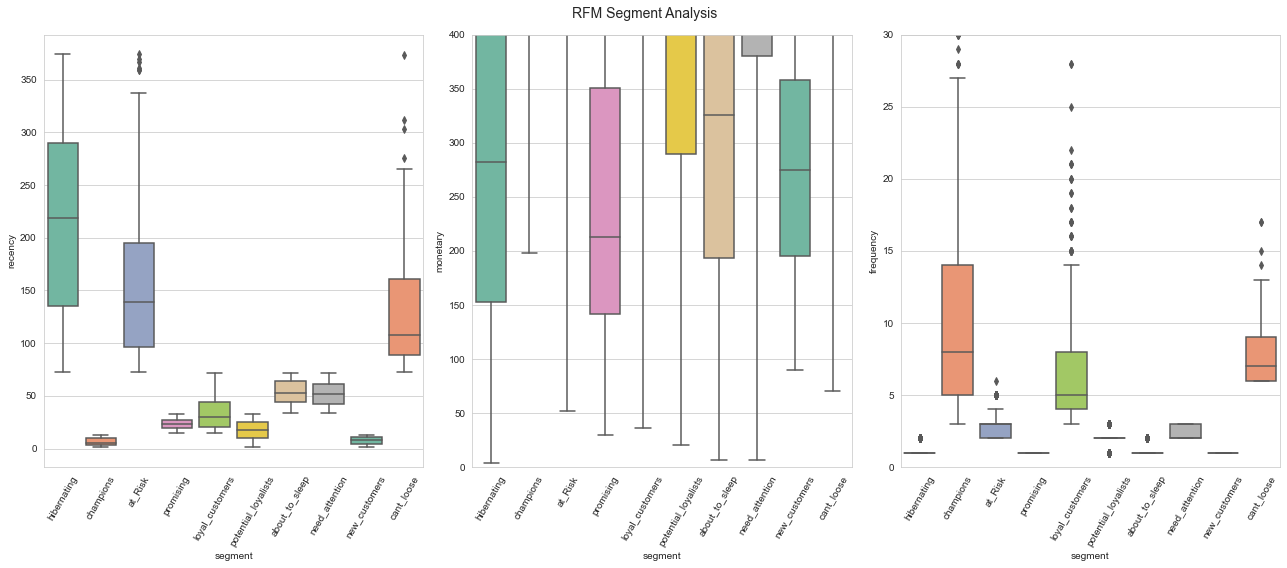

<IPython.core.display.Javascript object>

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle("RFM Segment Analysis", size=14)
feature_list = ["recency", "monetary", "frequency"]
for idx, col in enumerate(feature_list):
    sns.boxplot(
        ax=axes[idx], data=rfm, x="segment", y=feature_list[idx], palette=palette
    )
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=60)
    if idx == 1:
        axes[idx].set_ylim([0, 400])
    if idx == 2:
        axes[idx].set_ylim([0, 30])
plt.tight_layout()
plt.show()


# Cohort Analysis

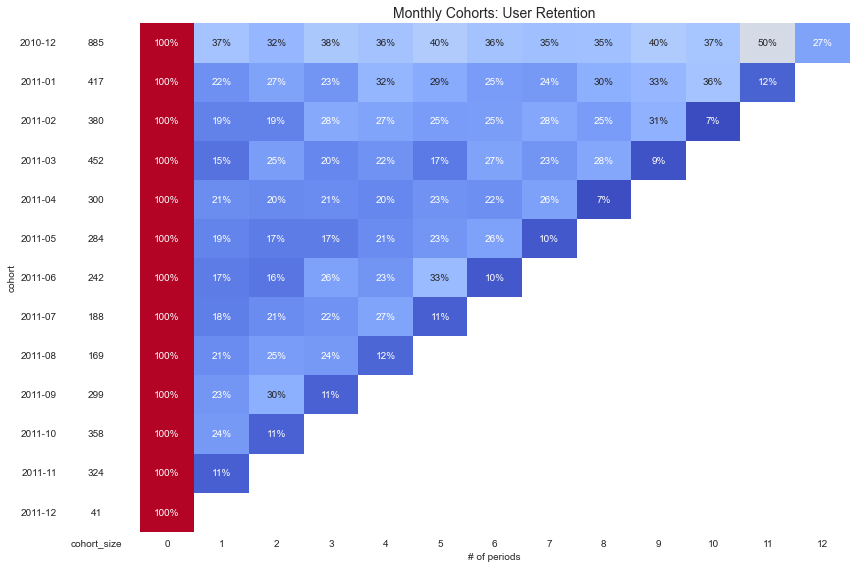

<IPython.core.display.Javascript object>

In [21]:
def CohortAnalysis(dataframe):

    data = dataframe.copy()
    data = data[["CustomerID", "InvoiceNo", "InvoiceDate"]].drop_duplicates()
    data["order_month"] = data["InvoiceDate"].dt.to_period("M")
    data["cohort"] = (
        data.groupby("CustomerID")["InvoiceDate"].transform(
            "min").dt.to_period("M")
    )
    cohort_data = (
        data.groupby(["cohort", "order_month"])
        .agg(n_customers=("CustomerID", "nunique"))
        .reset_index(drop=False)
    )
    cohort_data["period_number"] = (cohort_data.order_month - cohort_data.cohort).apply(
        attrgetter("n")
    )
    cohort_pivot = cohort_data.pivot_table(
        index="cohort", columns="period_number", values="n_customers"
    )
    cohort_size = cohort_pivot.iloc[:, 0]
    retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
    with sns.axes_style("white"):
        fig, ax = plt.subplots(
            1, 2, figsize=(12, 8), sharey=True, gridspec_kw={"width_ratios": [1, 11]}
        )
        sns.heatmap(
            retention_matrix,
            mask=retention_matrix.isnull(),
            annot=True,
            cbar=False,
            fmt=".0%",
            cmap="coolwarm",
            ax=ax[1],
        )
        ax[1].set_title("Monthly Cohorts: User Retention", fontsize=14)
        ax[1].set(xlabel="# of periods", ylabel="")
        white_cmap = mcolors.ListedColormap(["white"])
        sns.heatmap(
            pd.DataFrame(cohort_size).rename(columns={0: "cohort_size"}),
            annot=True,
            cbar=False,
            fmt="g",
            cmap=white_cmap,
            ax=ax[0],
        )
        fig.tight_layout()


CohortAnalysis(df)


# Customer Lifetime Value

In [22]:
cltv_df = df.groupby("CustomerID").agg(
    {
        "InvoiceDate": [
            lambda x: (x.max() - x.min()).days,
            lambda x: (today_date - x.min()).days,
        ],
        "InvoiceNo": "nunique",
        "TotalPrice": "sum",
    }
)

cltv_df.columns = cltv_df.columns.droplevel(0)
cltv_df.columns = ["recency", "T", "frequency", "monetary"]
cltv_df.head()


,recency,T,frequency,monetary
CustomerID,,,,
12346,0,326,1,310.44
12347,365,368,7,4310.00
12348,282,359,4,1770.78
12349,0,19,1,1491.72
12350,0,311,1,331.46


<IPython.core.display.Javascript object>

In [23]:
#Average Order Value
cltv_df["monetary"] = cltv_df["monetary"] / cltv_df["frequency"]

#Recency & Tenure
cltv_df["recency"] = cltv_df["recency"] / 7
cltv_df["T"] = cltv_df["T"] / 7

#Frequency
cltv_df = cltv_df[(cltv_df['frequency'] > 1)]


<IPython.core.display.Javascript object>

# BG/NBD

In [24]:
BGF = BetaGeoFitter(penalizer_coef=0.001)  # avoid overfitting

BGF.fit(cltv_df["frequency"], cltv_df["recency"], cltv_df["T"])


<lifetimes.BetaGeoFitter: fitted with 2845 subjects, a: 0.12, alpha: 11.40, b: 2.49, r: 2.18>

<IPython.core.display.Javascript object>

Top 10 Expected Number of Transaction (1 Week)

In [25]:
BGF.conditional_expected_number_of_purchases_up_to_time(
    1, cltv_df["frequency"], cltv_df["recency"], cltv_df["T"]
).sort_values(ascending=False).head(10).to_frame(
    "Expected Number of Transactions"
).reset_index()


,CustomerID,Expected Number of Transactions
0,12748,3.265158
1,14911,3.126645
2,17841,1.940290
3,13089,1.537528
4,14606,1.463999
5,15311,1.433717
6,12971,1.357024
7,14646,1.222517
8,13408,0.986249
9,18102,0.968607


<IPython.core.display.Javascript object>

# Frequency of Repeat Transactions

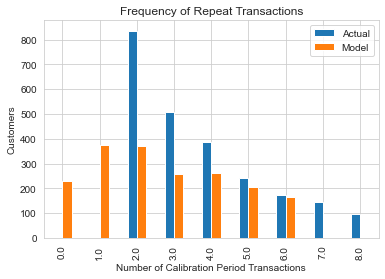

<IPython.core.display.Javascript object>

In [26]:
# Plot a figure with period actual and predicted transactions.
plot_period_transactions(BGF, max_frequency=7)
plt.show()
